### Building a Basic Chatbot with Langgraph(Graph API)

### Components of Langgraph
1. Edge
2. Nodes
3. States

There are two types of apis:
1. Graph API
2. Functional API

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ['GROQ_API_KEY']=os.getenv('LLM_API')


In [5]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [6]:
class State(TypedDict):
    # Messages have the type list. The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)

    messages:Annotated[list,add_messages]

graph_builder = StateGraph(State)

In [7]:
graph_builder

In [8]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model='llama-3.3-70b-versatile')

In [9]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7b32c6737910>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7b32c6607990>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [10]:
llm.profile

{'max_input_tokens': 131072,
 'max_output_tokens': 32768,
 'image_inputs': False,
 'audio_inputs': False,
 'video_inputs': False,
 'image_outputs': False,
 'audio_outputs': False,
 'video_outputs': False,
 'reasoning_output': False,
 'tool_calling': True}

In [11]:
# node functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

In [12]:
# adding node
graph_builder.add_node("chatbot",chatbot)
# adding edges
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

In [13]:
graph_builder

In [15]:
## compiling graph
graph=graph_builder.compile()

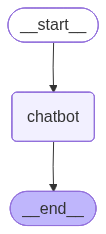

In [16]:
## Visualizing graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [23]:
response=graph.invoke({"messages":"Hi"})['messages'][1].content

In [24]:
response

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [29]:
for event in graph.stream({'messages':"What is AI?"}):
    for value in event.values():
        print(value['messages'][-1].content)

**Artificial Intelligence (AI)** refers to the development of computer systems that can perform tasks that typically require human intelligence, such as:

1. **Learning**: AI systems can learn from data and improve their performance over time.
2. **Problem-solving**: AI systems can analyze problems and find solutions.
3. **Reasoning**: AI systems can draw inferences and make decisions based on available data.
4. **Perception**: AI systems can interpret and understand data from sensors, such as images, speech, and text.

AI systems use a range of techniques, including:

1. **Machine learning**: AI systems can learn from data and improve their performance using algorithms and statistical models.
2. **Deep learning**: AI systems can use neural networks to analyze complex data, such as images and speech.
3. **Natural language processing**: AI systems can understand and generate human language.

AI has many applications, including:

1. **Virtual assistants**: AI-powered virtual assistants, 

## TOOLS

In [3]:
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

In [4]:
from langchain_tavily import TavilySearch
tool = TavilySearch(max_results=2)
tool.invoke('What is langgraph')

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://huggingface.co/learn/agents-course/en/unit2/langgraph/when_to_use_langgraph',
   'title': 'What is LangGraph - Hugging Face',
   'content': '`LangGraph` is a framework developed by LangChain **to manage the control flow of applications that integrate an LLM**. ## Is LangGraph different from LangChain ? The classes from LangChain might be used in LangGraph, but do not HAVE to be used. The packages are different and can be used in isolation, but, in the end, all resources you will find online use both packages hand in hand. `LangGraph` is on the other end of the spectrum, it shines when you need **“Control”** on the execution of your agent. LangGraph is particularly valuable when you need **Control over your applications**. It gives you the tools to build an application that follows a predictable process while still leveraging the power of LLMs. Put simply, if your a

In [5]:
## Custom function
def multiply(a:int, b:int)->int:
    """multiply two numbers

    Args:
        a (int): first number
        b (int): second number

    Returns:
        int: multiplication result of a and b
    """
    return a*b

In [6]:
tools = [tool,multiply]

In [7]:
from langchain.chat_models import init_chat_model
model = init_chat_model('groq:llama-3.3-70b-versatile')

llm_with_tools = model.bind_tools(tools=tools)

In [8]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x78f3bfa74a90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x78f3bf9dae10>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers re

In [15]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode, tools_condition
from typing import TypedDict
from typing_extensions import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list,add_messages]

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state['messages'])]}

## Graph
builder = StateGraph(State)
builder.add_node("toolcallingllm",tool_calling_llm)
builder.add_node('tools',ToolNode(tools))
builder.add_edge(START,'toolcallingllm')
builder.add_conditional_edges(
    "toolcallingllm",
    # if latest message from assistant is a tool call -> it routes to tools
    # otherwise it routes to end
    tools_condition
)
builder.add_edge('tools',END)
graph=builder.compile()

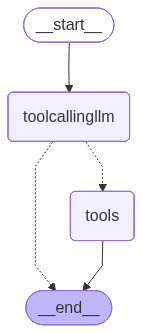

In [16]:
graph

In [20]:
response=graph.invoke({'messages':"What is recent AI news"})

In [23]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.washingtonpost.com/wp-intelligence/ai-tech-brief/2026/05/22/ai-tech-brief-tech-ceos-blocked-executive-order/", "title": "AI & Tech Brief: Tech CEOs blocked executive order - The Washington Post", "score": 0.67501575, "published_date": "Fri, 22 May 2026 19:00:04 GMT", "content": "AI & Tech Brief from WP Intelligence. # AI & Tech Brief: Tech CEOs blocked executive order. Plus, AI safety advocates are concerned about the trajectory of bipartisan discussions over AI preemption. * Former White House AI and crypto czar David Sacks and AI industry CEOs made 11th-hour calls to President Donald Trump to persuade him against signing his planned AI executive order. * New York Assembly members Alex Bores and Andrew Gounardes write a letter expressing concern over the recent bipartisan talks in the House over preemption of AI state laws. Operatives in the industry and AI safety c

In [24]:
response=graph.invoke({'messages':"What is 2 X 3"})

In [25]:
response['messages'][-1].content

'6'

### ReACT Agent architecture

In [26]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode, tools_condition
from typing import TypedDict
from typing_extensions import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list,add_messages]

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state['messages'])]}

## Graph
builder = StateGraph(State)
builder.add_node("toolcallingllm",tool_calling_llm)
builder.add_node('tools',ToolNode(tools))
builder.add_edge(START,'toolcallingllm')
builder.add_conditional_edges(
    "toolcallingllm",
    # if latest message from assistant is a tool call -> it routes to tools
    # otherwise it routes to end
    tools_condition
)
builder.add_edge('tools','toolcallingllm')
graph=builder.compile()

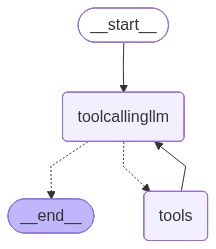

In [27]:
graph

In [28]:
graph.invoke({'messages':"Whats the latest AI news and then multiply 5 by 2"})

{'messages': [HumanMessage(content='Whats the latest AI news and then multiply 5 by 2', additional_kwargs={}, response_metadata={}, id='e5e013a4-230a-4cf9-8b20-ffc1beab4c8f'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 't9zzhnpx8', 'function': {'arguments': '{"query":"latest AI news","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}, {'id': '9yerb4nxg', 'function': {'arguments': '{"a":5,"b":2}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 1756, 'total_tokens': 1798, 'completion_time': 0.098678036, 'completion_tokens_details': None, 'prompt_time': 0.176168207, 'prompt_tokens_details': None, 'queue_time': 0.162725695, 'total_time': 0.274846243}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5488-2742-7881-9db2-65e2475a3de9-0

### Adding Memory in Agentic Graph

In [ ]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode, tools_condition
from typing import TypedDict
from typing_extensions import Annotated
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()

class State(TypedDict):
    messages:Annotated[list,add_messages]

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state['messages'])]}

## Graph
builder = StateGraph(State)
builder.add_node("toolcallingllm",tool_calling_llm)
builder.add_node('tools',ToolNode(tools))
builder.add_edge(START,'toolcallingllm')
builder.add_conditional_edges(
    "toolcallingllm",
    # if latest message from assistant is a tool call -> it routes to tools
    # otherwise it routes to end
    tools_condition
)
builder.add_edge('tools','toolcallingllm')
graph=builder.compile(checkpointer=memory)

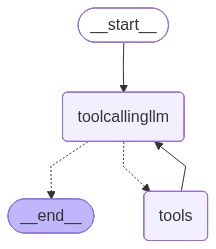

In [30]:
graph

In [33]:
config = {"configurable":{"thread_id":"session-1"}}
response=graph.invoke({'messages':"Hi my name is Rahul"},config=config)['messages'][-1].content
response

"Hello Rahul, it's nice to meet you. Is there something I can help you with or would you like to chat?"

In [34]:
response=graph.invoke({'messages':"What is my name"},config=config)['messages'][-1].content


In [35]:
response

'Your name is Rahul.'

### Streaming in Langgraph

In [47]:
from langgraph.checkpoint.memory import MemorySaver
from langchain.chat_models import init_chat_model
llm = init_chat_model('groq:llama-3.3-70b-versatile')

memory=MemorySaver()

In [48]:
def superbot(state:State):
    return {'messages':[llm.invoke(state['messages'])]}

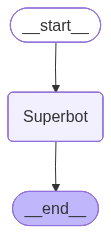

In [49]:
graph = StateGraph(State)
graph.add_node("Superbot",superbot)
graph.add_edge(START,'Superbot')
graph.add_edge('Superbot',END)
graph_builder=graph.compile(checkpointer=memory)
graph_builder

In [50]:
config = {'configurable':{'thread_id':"1"}}
graph_builder.invoke({"messages":"MY name is rahul I like cricket"},config=config)

{'messages': [HumanMessage(content='MY name is rahul I like cricket', additional_kwargs={}, response_metadata={}, id='51ae1f9d-ccfa-44a1-9bc1-68b2d556f0ab'),
  AIMessage(content="Nice to meet you, Rahul. Cricket is an exciting sport, and it's great that you're a fan. Who's your favorite cricketer, and do you have a favorite team that you support?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 44, 'total_tokens': 87, 'completion_time': 0.142344988, 'completion_tokens_details': None, 'prompt_time': 0.001973305, 'prompt_tokens_details': None, 'queue_time': 0.056417004, 'total_time': 0.144318293}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5493-1aeb-7b13-8473-95d3b000a76f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 43, 'total_tokens': 87

### Two Streaming methods
#### .stream() sync method
#### .astream() async method

In [55]:
config = {'configurable':{'thread_id':"3"}}
for chunk in graph_builder.stream({"messages":"MY name is rahul I like cricket"},config=config,stream_mode='values'):
    print(chunk)

{'messages': [HumanMessage(content='MY name is rahul I like cricket', additional_kwargs={}, response_metadata={}, id='03c343e9-036f-46bb-aa2a-b9dc742f87c8'), AIMessage(content="Nice to meet you, Rahul. Cricket is an exciting sport, and it's great that you're a fan. Who's your favorite cricket team or player? Do you play cricket yourself or enjoy watching it?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 44, 'total_tokens': 87, 'completion_time': 0.169651535, 'completion_tokens_details': None, 'prompt_time': 0.002013765, 'prompt_tokens_details': None, 'queue_time': 0.058376065, 'total_time': 0.1716653}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e549a-a911-7fc1-b636-b43d231b6113-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 43, 'total_t

### Human in the loop

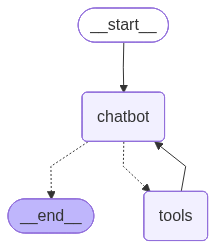

In [63]:
from typing import Annotated
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import Command, interrupt

class State(TypedDict):
    messages:Annotated[list,add_messages]

graph_builder = StateGraph(State)

@tool
def human_assistance(query:str)->str:
    """Request help from human"""
    human_res = interrupt({"query":query})
    return human_res['data']

tool = TavilySearch(max_results=2)
tools = [tool,human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state:State):
    return {'messages':[llm_with_tools.invoke(state['messages'])]}

graph_builder.add_node("chatbot",chatbot)
graph_builder.add_node('tools',ToolNode(tools))
graph_builder.add_conditional_edges("chatbot",tools_condition)
graph_builder.add_edge("tools","chatbot")
graph_builder.add_edge(START,"chatbot")
graph=graph_builder.compile(checkpointer=MemorySaver())
graph


In [67]:
user_input = "I need some for building an AI agent. Could you request assistance for me?"
config = {'configurable':{'thread_id':'1'}}
events = graph.stream(
    {'messages':user_input},
    config,
    stream_mode='values'
)
for event in events:
    if 'messages' in event:
        print(event['messages'][-1].pretty_print())

================================ Human Message =================================

I need some for building an AI agent. Could you request assistance for me?
None
================================== Ai Message ==================================
Tool Calls:
  human_assistance (wa5xg4wpj)
 Call ID: wa5xg4wpj
  Args:
    query: I need assistance with building an AI agent.
None
================================== Ai Message ==================================
Tool Calls:
  human_assistance (wa5xg4wpj)
 Call ID: wa5xg4wpj
  Args:
    query: I need assistance with building an AI agent.
None


In [68]:
human_response = (
    "We, the experts, are here to help! We'd recommend you check out langgraph to build your agent"
)

human_command = Command(resume={"data":human_response})

events = graph.stream(human_command,config,stream_mode='values')
for event in events:
    if "messages" in event:
        event['messages'][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (wa5xg4wpj)
 Call ID: wa5xg4wpj
  Args:
    query: I need assistance with building an AI agent.
================================= Tool Message =================================
Name: human_assistance

We, the experts, are here to help! We'd recommend you check out langgraph to build your agent
================================== Ai Message ==================================
Tool Calls:
  human_assistance (2jr4gt8pb)
 Call ID: 2jr4gt8pb
  Args:
    query: building an AI agent using langchain and python.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (2jr4gt8pb)
 Call ID: 2jr4gt8pb
  Args:
    query: building an AI agent using langchain and python.
